In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , regularizers

In [2]:
df = pd.read_csv("data/covid_pneumonia_flu_deaths_us.csv")
df.head()

,Data as of,Start Date,End Date,Group,Year,Month,MMWR Week,Week Ending Date,State,COVID-19 Deaths,Total Deaths,Percent of Expected Deaths,Pneumonia Deaths,Pneumonia and COVID-19 Deaths,Influenza Deaths,"Pneumonia, Influenza, or COVID-19 Deaths",Footnote
0,07/30/2026,12/29/2019,01/04/2020,By Week,2019/2020,NaN,1.0,01/04/2020,United States,0,"60,170",98.0,"4,111",0,434,"4,545",NaN
1,07/30/2026,01/05/2020,01/11/2020,By Week,2020,NaN,2.0,01/11/2020,United States,1,"60,734",97.0,"4,153",1,475,"4,628",NaN
2,07/30/2026,01/12/2020,01/18/2020,By Week,2020,NaN,3.0,01/18/2020,United States,2,"59,362",98.0,"4,066",2,468,"4,534",NaN
3,07/30/2026,01/19/2020,01/25/2020,By Week,2020,NaN,4.0,01/25/2020,United States,3,"59,162",99.0,"3,915",0,500,"4,418",NaN
4,07/30/2026,01/26/2020,02/01/2020,By Week,2020,NaN,5.0,02/01/2020,United States,0,"58,834",99.0,"3,818",0,481,"4,299",NaN


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23220 entries, 0 to 23219
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Data as of                                23220 non-null  object 
 1   Start Date                                23220 non-null  object 
 2   End Date                                  23220 non-null  object 
 3   Group                                     23220 non-null  object 
 4   Year                                      23166 non-null  object 
 5   Month                                     4266 non-null   float64
 6   MMWR Week                                 18522 non-null  float64
 7   Week Ending Date                          18522 non-null  object 
 8   State                                     23220 non-null  object 
 9   COVID-19 Deaths                           16865 non-null  object 
 10  Total Deaths                      

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Group'] = le.fit_transform(df['Group'])

In [5]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

df['date_range'] = (df['End Date'] - df['Start Date']).dt.days

col = df.pop('date_range')
df.insert(1, 'date_range', col)

df['Month'] = df['Month'].fillna(df['Start Date'].dt.month)
df['End_Month'] = df['End Date'].dt.month
df["month_diff"] = (
    (df["End Date"] - df["Start Date"]).dt.days / 30.44
)

df['MMWR Week'] = df['MMWR Week'].fillna(
    df['Start Date'].dt.isocalendar().week
)

In [6]:
df.drop(columns=["Start Date" , "End Date" , "Data as of" , "Year" , "Week Ending Date"  , "Footnote"] , inplace=True)

In [7]:
numeric_col = [ "COVID-19 Deaths" , "Total Deaths" , "Pneumonia Deaths" , "Pneumonia and COVID-19 Deaths" , "Influenza Deaths" , "Pneumonia, Influenza, or COVID-19 Deaths" , "Percent of Expected Deaths" ]

for i in numeric_col:
    df[i] = pd.to_numeric(
        df[i].astype(str).str.replace(',', ''),
        errors='coerce'
    )


<Axes: >

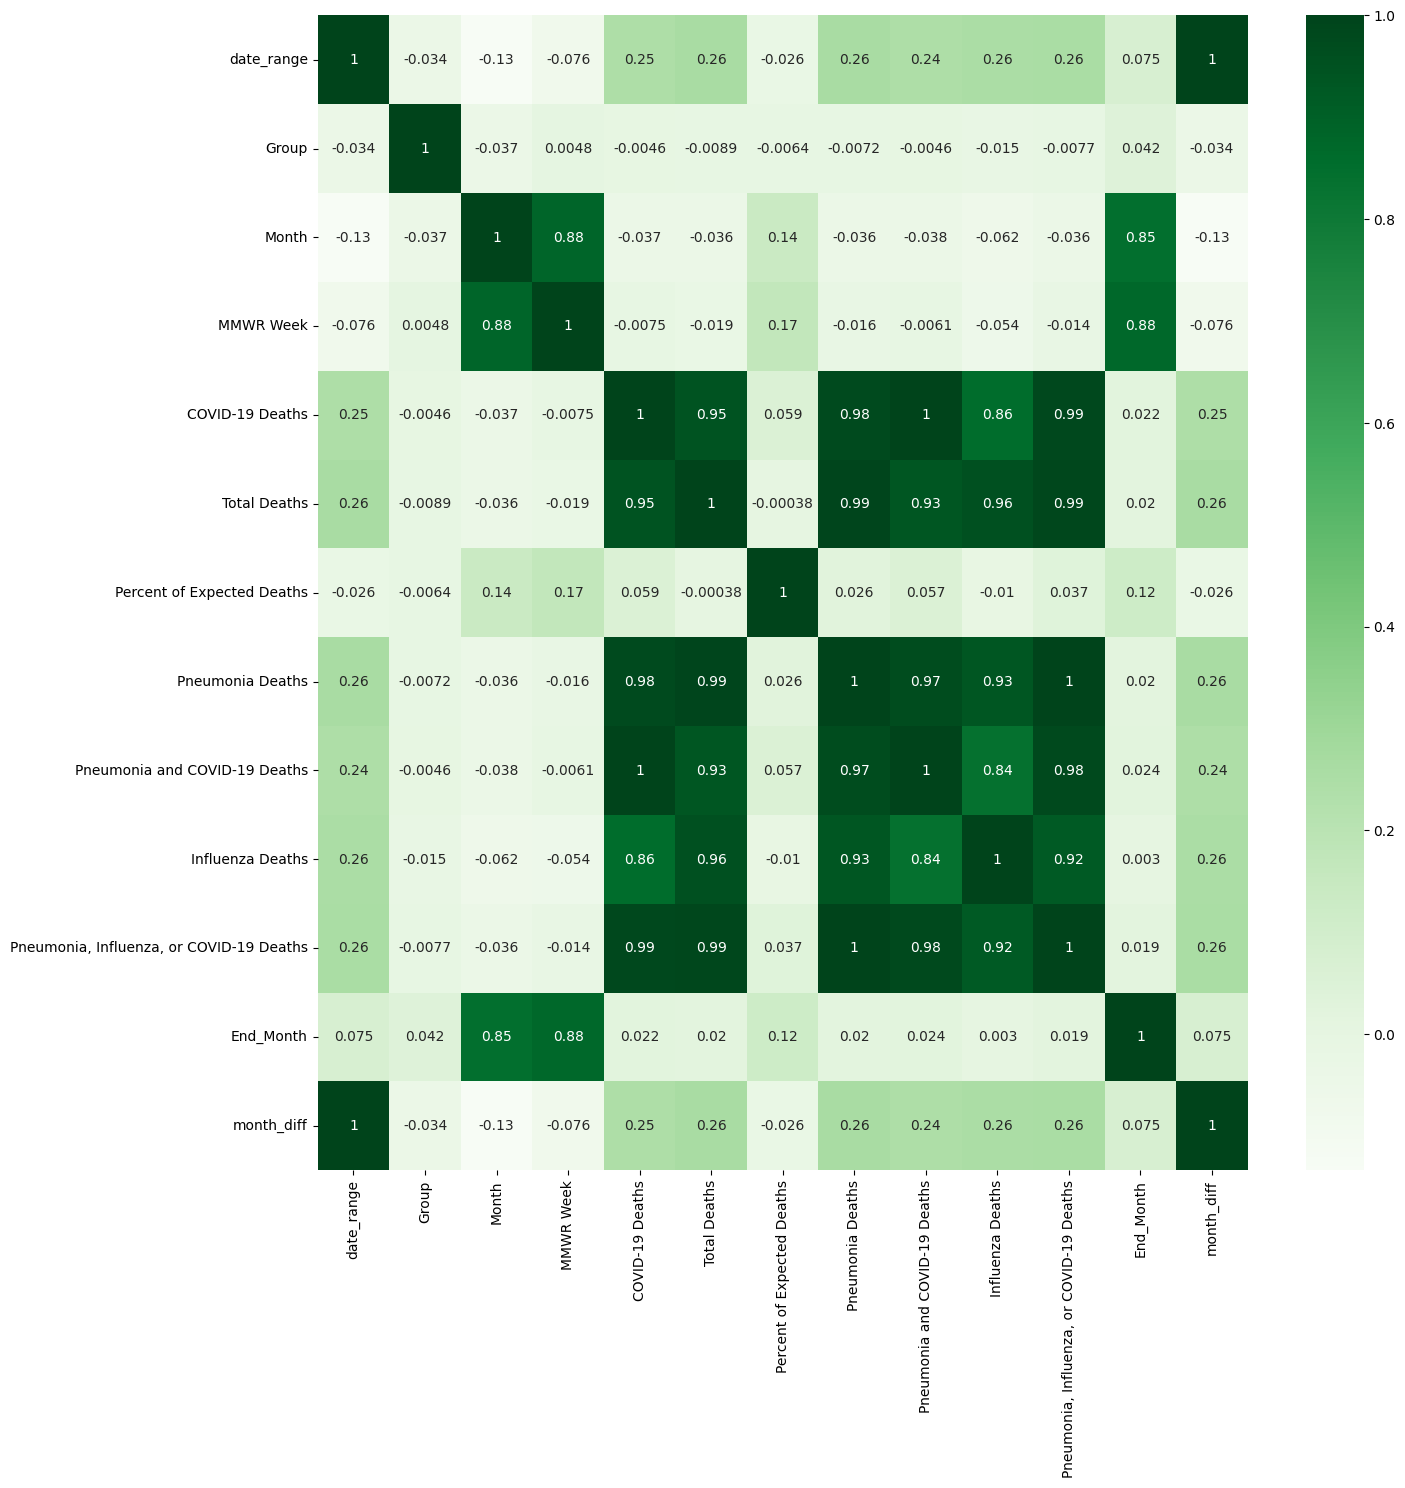

In [8]:
corr = df.drop(columns=["State"]).corr()

plt.figure(figsize=(15,15))

sns.heatmap(corr , cmap="Greens", annot=True)

In [9]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['State']

oe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded = oe.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=oe.get_feature_names_out(categorical_cols),
    index=df.index
)

df = pd.concat(
    [
        df.drop(columns=categorical_cols),
        encoded_df
    ],
    axis=1
)

In [10]:
col = df.pop('COVID-19 Deaths')
df['COVID-19 Deaths'] = col

In [11]:
df = df.dropna(subset=["COVID-19 Deaths"])

In [12]:
df.head()

,date_range,Group,Month,MMWR Week,Total Deaths,Percent of Expected Deaths,Pneumonia Deaths,Pneumonia and COVID-19 Deaths,Influenza Deaths,"Pneumonia, Influenza, or COVID-19 Deaths",...,State_Texas,State_United States,State_Utah,State_Vermont,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming,COVID-19 Deaths
0,6,2,12.0,1.0,60170.0,98.0,4111.0,0.0,434.0,4545.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6,2,1.0,2.0,60734.0,97.0,4153.0,1.0,475.0,4628.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,6,2,1.0,3.0,59362.0,98.0,4066.0,2.0,468.0,4534.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,6,2,1.0,4.0,59162.0,99.0,3915.0,0.0,500.0,4418.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
4,6,2,1.0,5.0,58834.0,99.0,3818.0,0.0,481.0,4299.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16865 entries, 0 to 23219
Data columns (total 67 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   date_range                                16865 non-null  int64  
 1   Group                                     16865 non-null  int64  
 2   Month                                     16865 non-null  float64
 3   MMWR Week                                 16865 non-null  float64
 4   Total Deaths                              16864 non-null  float64
 5   Percent of Expected Deaths                16811 non-null  float64
 6   Pneumonia Deaths                          16271 non-null  float64
 7   Pneumonia and COVID-19 Deaths             12787 non-null  float64
 8   Influenza Deaths                          9903 non-null   float64
 9   Pneumonia, Influenza, or COVID-19 Deaths  16365 non-null  float64
 10  End_Month                              

In [14]:
x = df.iloc[: , 0:-1].values
y = df.iloc[: , -1].values

In [15]:
x

array([[6.000e+00, 2.000e+00, 1.200e+01, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [6.000e+00, 2.000e+00, 1.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [6.000e+00, 2.000e+00, 1.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       ...,
       [2.397e+03, 1.000e+00, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [2.397e+03, 1.000e+00, 1.000e+00, ..., 0.000e+00, 0.000e+00,
        1.000e+00],
       [2.397e+03, 1.000e+00, 1.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00]], shape=(16865, 66))

In [16]:
y.mean()

np.float64(591.2378891194782)

In [17]:
from sklearn.preprocessing import StandardScaler

mm = StandardScaler()

x = mm.fit_transform(x)

In [18]:
x.shape

(16865, 66)

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [43]:
model = keras.Sequential([
    
    layers.Input(shape=(x_train.shape[1],)),

    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.Dropout(0.15),

    layers.Dense(32, activation="relu"),

    # خروجی رگرسیون
    layers.Dense(1)
])

In [44]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE")
    ]
)

In [45]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6
    )
]

In [46]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=64,
    verbose=1,
)

Epoch 1/300


169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - MAE: 620.6044 - loss: nan - val_MAE: 644.3277 - val_loss: nan
Epoch 2/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 613.6877 - loss: nan - val_MAE: 643.9043 - val_loss: nan
Epoch 3/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 613.5561 - loss: nan - val_MAE: 643.7984 - val_loss: nan
Epoch 4/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MAE: 613.3589 - loss: nan - val_MAE: 644.0718 - val_loss: nan
Epoch 5/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 613.3626 - loss: nan - val_MAE: 643.7354 - val_loss: nan
Epoch 6/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 613.3010 - loss: nan - val_MAE: 643.9086 - val_loss: nan
Epoch 7/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 613.4297 - loss: nan - val_MAE: 643.7883 - val_loss: nan
Epoch 8/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 613.2523 - loss: nan - val_MAE: 644.1333 - val_loss: nan
Epoch 9/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 613.2983 - loss:

KeyboardInterrupt: 

In [21]:
y_pred = model.predict(x_test)


106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error , mean_squared_error , r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 38.95127602116838
MSE: 220335.03582503911
RMSE: 469.3985895004789
R2: 0.9716537456793292


In [ ]:
error = y_pred - y_test

print("میانگین خطا:", np.mean(error))
print("بیشترین خطای مثبت:", np.max(error))
print("بیشترین خطای منفی:", np.argmin(error))

میانگین خطا: 0.6017170431387268
بیشترین خطای مثبت: 8882.91796875
بیشترین خطای منفی: 3274


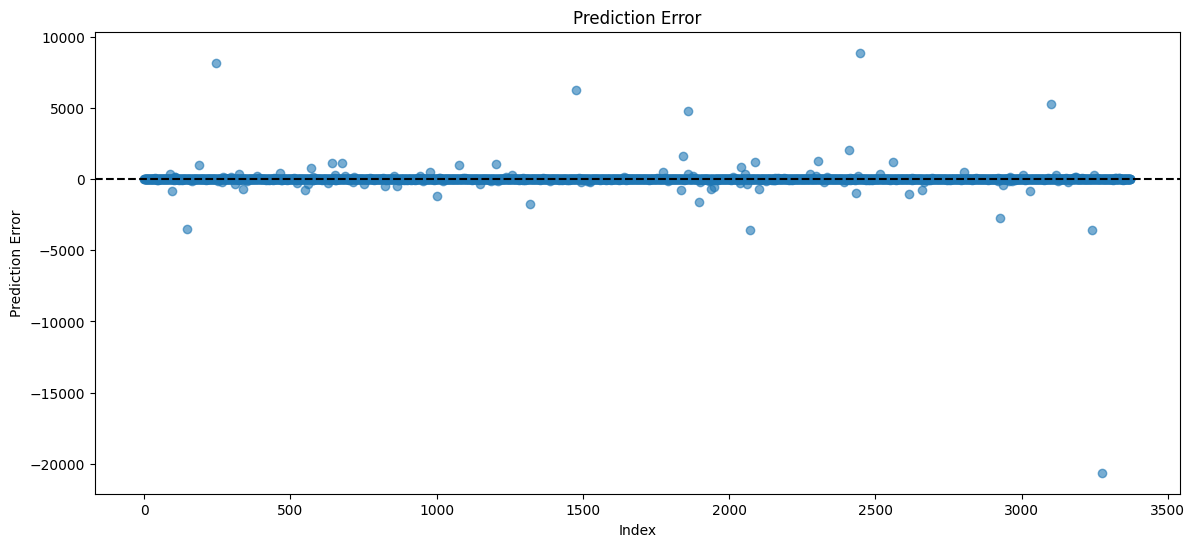

In [ ]:
plt.figure(figsize=(14, 6))

plt.scatter(range(len(error)), error, alpha=0.6)

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Index")
plt.ylabel("Prediction Error")
plt.title("Prediction Error")

plt.show()

C:\Users\Mesbah\AppData\Local\Temp\ipykernel_7296\1432789626.py:1: RuntimeWarning: divide by zero encountered in divide
  error_percent = ((y_pred - y_test) / y_test) * 100


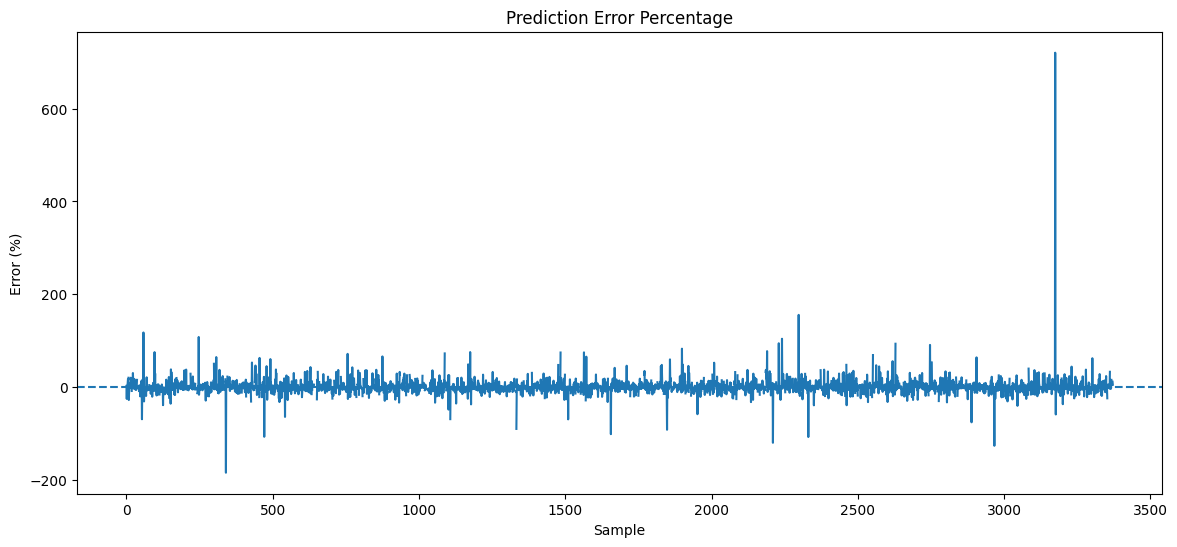

In [ ]:
error_percent = ((y_pred - y_test) / y_test) * 100

plt.figure(figsize=(14, 6))

plt.plot(error_percent)

plt.axhline(0, linestyle="--")

plt.xlabel("Sample")
plt.ylabel("Error (%)")
plt.title("Prediction Error Percentage")

plt.show()

C:\Users\Mesbah\AppData\Local\Temp\ipykernel_7296\1866918040.py:5: RuntimeWarning: divide by zero encountered in divide
  error_percent = np.abs((y_pred - y_test) / y_test) * 100


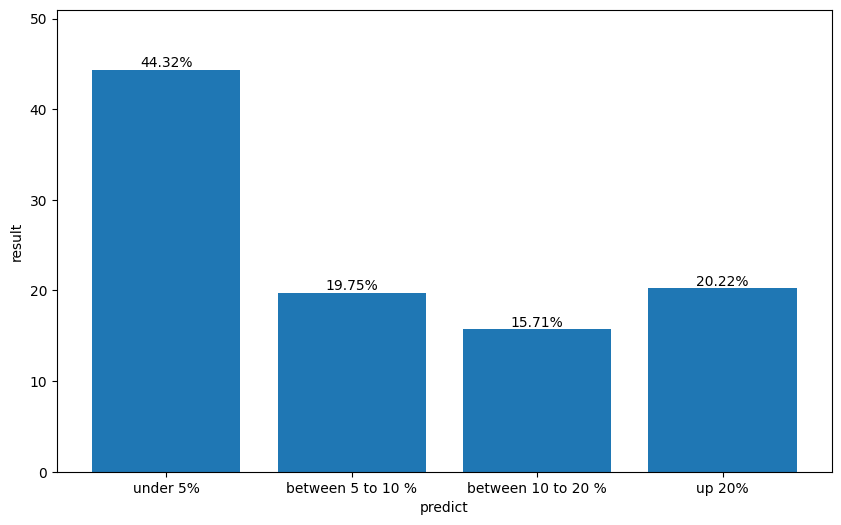

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# درصد خطای مطلق
error_percent = np.abs((y_pred - y_test) / y_test) * 100

# دسته‌بندی خطا
categories = {
    "under 5%": np.sum(error_percent < 5),
    "between 5 to 10 %": np.sum((error_percent >= 5) & (error_percent < 10)),
    "between 10 to 20 %": np.sum((error_percent >= 10) & (error_percent < 20)),
    "up 20%": np.sum(error_percent >= 20)
}

# تبدیل به درصد از کل نمونه‌ها
total = len(error_percent)

category_percent = {
    key: (value / total) * 100
    for key, value in categories.items()
}

# رسم نمودار
plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_percent.keys(),
    category_percent.values()
)

plt.ylabel("result")
plt.xlabel("predict")

# نمایش مقدار روی هر ستون
for bar, value in zip(bars, category_percent.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(category_percent.values()) * 1.15)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# درصد خطای مطلق
error_percent = np.abs((y_pred - y_test) / y_test) * 100

# نمونه‌هایی که خطای بالای 20٪ دارند
mask = error_percent > 20

y_test_high = np.array(y_test)[mask]
y_pred_high = np.array(y_pred)[mask]
error_high = error_percent[mask]

print("تعداد خطاهای بالای 20٪:", len(y_test_high))

تعداد خطاهای بالای 20٪: 682


C:\Users\Mesbah\AppData\Local\Temp\ipykernel_7296\1200922226.py:5: RuntimeWarning: divide by zero encountered in divide
  error_percent = np.abs((y_pred - y_test) / y_test) * 100


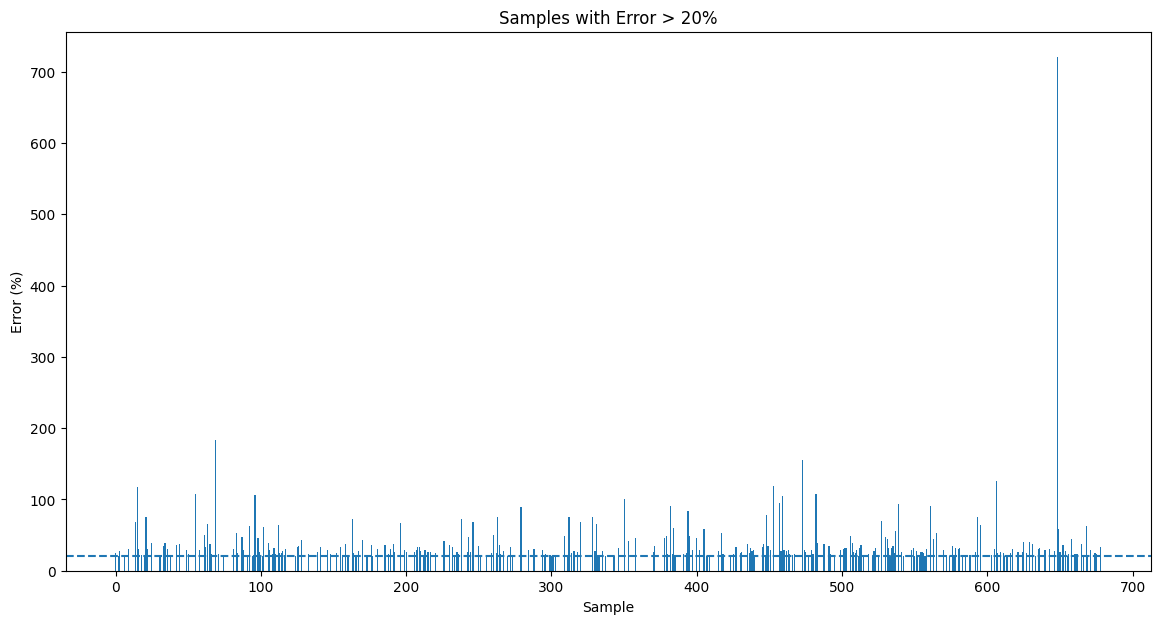

In [ ]:
plt.figure(figsize=(14, 7))

plt.bar(
    range(len(error_high)),
    error_high
)

plt.axhline(20, linestyle="--")

plt.xlabel("Sample")
plt.ylabel("Error (%)")
plt.title("Samples with Error > 20%")

plt.show()

In [ ]:

# تبدیل به آرایه یک‌بعدی
y_test_np = np.asarray(y_test).ravel()
y_pred_np = np.asarray(y_pred).ravel()

# محاسبه درصد خطای مطلق
error_percent = (
    np.abs((y_pred_np - y_test_np) / y_test_np)
) * 100

# فقط خطاهای بالای 20 درصد
mask = error_percent > 20

# X_test مربوط به همین نمونه‌ها
X_bad = x_test[mask]

# برگرداندن x_test از حالت StandardScaler به مقادیر اصلی
X_bad_original = mm.inverse_transform(X_bad)

bad_rows = pd.DataFrame(
    X_bad_original,
    columns=df.drop(columns=["COVID-19 Deaths"]).columns
)

# اضافه کردن اطلاعات پیش‌بینی
bad_rows["Actual"] = y_test_np[mask]
bad_rows["Predicted"] = y_pred_np[mask]

bad_rows["Error"] = (
    y_pred_np[mask] - y_test_np[mask]
)

bad_rows["Error_Percent"] = error_percent[mask]

# مرتب‌سازی از بیشترین خطا به کمترین
bad_rows = bad_rows.sort_values(
    "Error_Percent",
    ascending=False
)

bad_rows

C:\Users\Mesbah\AppData\Local\Temp\ipykernel_7296\65453043.py:7: RuntimeWarning: divide by zero encountered in divide
  np.abs((y_pred_np - y_test_np) / y_test_np)


,date_range,Group,Month,MMWR Week,Total Deaths,Percent of Expected Deaths,Pneumonia Deaths,Pneumonia and COVID-19 Deaths,Influenza Deaths,"Pneumonia, Influenza, or COVID-19 Deaths",...,State_Vermont,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming,Actual,Predicted,Error,Error_Percent
681,6.0,2.0,6.0,26.0,102.0,132.0,NaN,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,3.469447e-18,0.0,0.0,-0.055887,-0.055887,inf
680,24.0,0.0,7.0,27.0,1749.0,69.0,84.0,0.0,NaN,86.0,...,0.0,0.0,0.0,0.0,3.469447e-18,0.0,0.0,-0.602526,-0.602526,inf
1,6.0,2.0,2.0,7.0,281.0,116.0,23.0,0.0,NaN,26.0,...,0.0,0.0,0.0,0.0,3.469447e-18,0.0,0.0,0.376326,0.376326,inf
679,6.0,2.0,8.0,35.0,147.0,130.0,NaN,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,3.469447e-18,0.0,0.0,0.129348,0.129348,inf
677,24.0,0.0,7.0,27.0,742.0,55.0,40.0,0.0,0.0,40.0,...,0.0,0.0,0.0,0.0,3.469447e-18,0.0,0.0,-0.138965,-0.138965,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,205.0,3.0,1.0,1.0,19222.0,60.0,1083.0,27.0,73.0,1184.0,...,0.0,0.0,0.0,0.0,3.469447e-18,0.0,55.0,66.033226,11.033226,20.060411
38,30.0,0.0,1.0,1.0,1012.0,110.0,50.0,NaN,16.0,74.0,...,0.0,0.0,0.0,0.0,3.469447e-18,0.0,10.0,12.002637,2.002637,20.026369
233,6.0,2.0,8.0,35.0,1414.0,114.0,72.0,NaN,0.0,89.0,...,0.0,1.0,0.0,0.0,3.469447e-18,0.0,24.0,19.197130,-4.802870,20.011957
273,6.0,2.0,9.0,38.0,850.0,116.0,49.0,NaN,0.0,58.0,...,0.0,0.0,0.0,0.0,3.469447e-18,0.0,12.0,14.400737,2.400737,20.006140


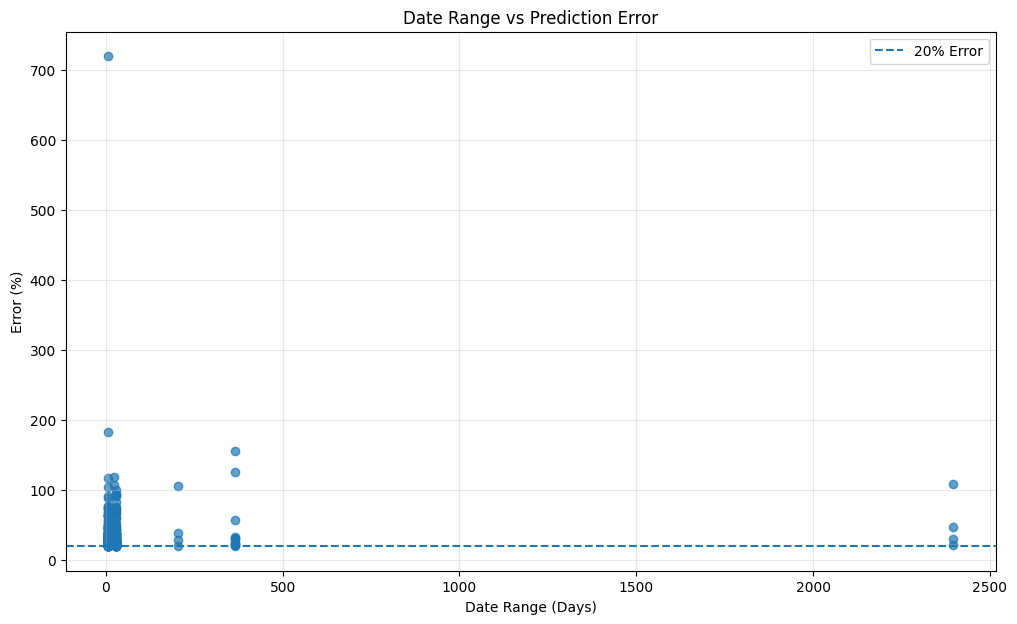

In [ ]:
bad_rows = bad_rows.sort_values("date_range")

bad_rows[[
    "date_range",
    "Actual",
    "Predicted",
    "Error_Percent"
]]


plt.figure(figsize=(12, 7))

plt.scatter(
    bad_rows["date_range"],
    bad_rows["Error_Percent"],
    alpha=0.7
)

plt.axhline(
    20,
    linestyle="--",
    label="20% Error"
)

plt.xlabel("Date Range (Days)")
plt.ylabel("Error (%)")
plt.title("Date Range vs Prediction Error")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

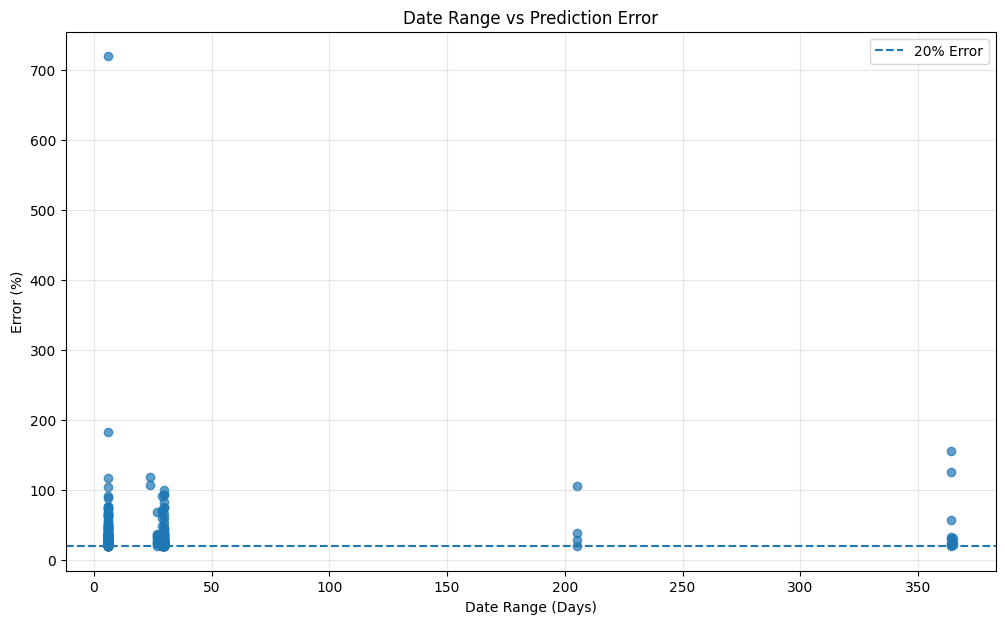

In [ ]:
filtered = bad_rows[
    (bad_rows["date_range"] >= 0) &
    (bad_rows["date_range"] <= 400)
]

plt.figure(figsize=(12, 7))

plt.scatter(
    filtered["date_range"],
    filtered["Error_Percent"],
    alpha=0.7
)

plt.axhline(20, linestyle="--", label="20% Error")

plt.xlabel("Date Range (Days)")
plt.ylabel("Error (%)")
plt.title("Date Range vs Prediction Error")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
mean_error = (
    bad_rows
    .groupby("date_range")["Error_Percent"]
    .mean()
    .reset_index()
)

mean_error

,date_range,Error_Percent
0,6.0,inf
1,24.0,inf
2,27.0,33.264259
3,28.0,inf
4,29.0,inf
5,30.0,inf
6,205.0,48.464363
7,364.0,58.640317
8,365.0,26.764533
9,2397.0,52.152234


In [ ]:
x_test[[3274]]

array([[ 0.02558705, -1.83870044, -1.44165291,  1.73058614,  2.03894189,
         1.3648136 ,  4.7070354 ,  8.59513143,  0.1365277 ,  5.71658056,
        -1.51105224,  0.02558705, -0.14083434, -0.10702785, -0.14663601,
        -0.136841  , -0.15646285, -0.14300833, -0.13503115, -0.11602038,
        -0.11549433, -0.15646285, -0.14852363, -0.10954999, -0.12266477,
        -0.14914798, -0.14852363, -0.13571247, -0.13180846, -0.14852363,
        -0.13593887, -0.11836021, -0.14747768, -0.14684684, -0.15080138,
        -0.14493925, -0.14105313, -0.14386946, -0.11201799, -0.12561959,
        -0.13273665, -0.11470098, -0.14935557, -0.13388847, -0.15446252,
        -0.1427923 , -0.15325097, -0.11010298, -0.15264192, -0.14322406,
        -0.13929395, -0.15526545, -0.13411773, -0.11174633, -0.144084  ,
        -0.11336702, -0.14831498, -0.15546559,  6.18230784, -0.12415043,
        -0.1032811 , -0.14831498, -0.14600184, -0.13250517, -0.1427923 ,
        -0.11010298]])

In [ ]:
y_test[[3274]]

array([105566.])

In [ ]:
y_pred[[3274]]

array([84935.58], dtype=float32)

In [ ]:
np.where(y_test < 600)

(array([   0,    1,    2, ..., 3369, 3370, 3371], shape=(3114,)),)

In [ ]:
y_pred = model.predict(x_test[[3369]])


In [ ]:
choised_y_test = y_test[[3369]]

mae = mean_absolute_error(choised_y_test, y_pred)
mse = mean_squared_error(choised_y_test, y_pred)
rmse = root_mean_squared_error(choised_y_test, y_pred)
r2 = r2_score(choised_y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("data:", choised_y_test)
print("result:", y_pred)

MAE: 1.8817825317382812
MSE: 3.5411054967553355
RMSE: 1.8817825317382812
R2: nan
data: [48.]
result: [49.881783]


c:\Users\Mesbah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
